# QuickCW demo: power-law vs. free-spectral noise models

This notebook demonstrates how to select and run the noise spectral models available in this fork of QuickCW:

- **Per-pulsar red noise**: `psr_noise_model='powerlaw'` (default; parameters `{psr}_red_noise_gamma`, `{psr}_red_noise_log10_A`) or `psr_noise_model='free_spectral'` (parameters `{psr}_red_noise_log10_rho_0 ... _{n-1}`, one per frequency bin, in every pulsar).
- **GWB / common red noise**: `gwb_noise_model='powerlaw'` (parameters `gwb_gamma`, `gwb_log10_A`) or `gwb_noise_model='free_spectral'` (parameters `gwb_log10_rho_0 ... _{n-1}`).

Any combination of the two options is supported. The number of frequency bins is controlled by `ChainParams(rn_comps=..., gwb_comps=...)`, and the prior ranges on the `log10_rho` parameters by the `log10_rho_prior` / `gwb_log10_rho_prior` arguments of `QuickCW` (default `[-9, -4]`).

The demo uses the tiny artificial 3-pulsar dataset in `tests/data` (generated by `tests/make_fake_data.py`).

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

import QuickCW.QuickCW as QCW
from QuickCW.QuickMCMCUtils import ChainParams

with open('tests/data/fake_psrs.pkl', 'rb') as f:
    psrs = pickle.load(f)
print([p.name for p in psrs])

Number of cores used for parallel running:  14


/opt/anaconda3/envs/PTAGlobal/lib/python3.11/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
libstempo not installed. PINT or libstempo are required to use par and tim files.


adjusted number multiple tries from 2000 to be next even divisor of n_x0_extra=14, 2002
['J0000+0000', 'J0600+3000', 'J1200-3000']


## Setting up the sampler

`ChainParams` controls the MCMC settings. The settings below are deliberately tiny so the demo runs in under a minute -- use many more samples/chains for real analyses.

In [2]:
chain_params = ChainParams(T_max=4.0,
                           n_chain=2,
                           n_block_status_update=10,
                           n_int_block=100,
                           n_update_fisher=1_000,
                           save_every_n=1_000,
                           fisher_eig_downsample=2,
                           savefile='tests/data/demo_chain.h5',
                           thin=10,
                           rn_comps=5,     # number of frequency bins in the per-pulsar red noise model
                           gwb_comps=5,    # number of frequency bins in the GWB model
                           de_history_size=100,
                           thin_de=100,
                           verbosity=0)

Using 2 temperature chains with a geometric spacing of 4.000.
Temperature ladder is:
 [1. 4.]


## Selecting the noise models

The spectral models are selected with the `psr_noise_model` and `gwb_noise_model` arguments of `QuickCW`. Here we use the free-spectral model for both the per-pulsar noise and the GWB; for power-law just pass `'powerlaw'` (or omit the argument) instead.

In [3]:
pta, mcc = QCW.QuickCW(chain_params, psrs,
                       noise_json='tests/data/fake_noisedict.json',
                       include_ecorr=False,        # simulated data has no ECORR
                       backend_selection=False,    # simulated data has a single backend
                       amplitude_prior='detection',
                       psr_noise_model='free_spectral',   # 'powerlaw' or 'free_spectral'
                       gwb_noise_model='free_spectral')   # 'powerlaw' or 'free_spectral'

# the free spectral parameters are visible in the parameter list:
print([p for p in mcc.par_names if 'log10_rho' in p])

Began Main Loop
Found lower frequency bound of nan - Setting it to 1/T.
Begin Loading Pulsar Timing Array from Enterprise at    0.039s
Finished Loading Pulsar Timing Array from Enterprise at    0.039s
[ -1. -18.   0.   0.   0.   0.   0.]
[  1.         -11.           6.28318531   3.14159265   6.28318531
   6.28318531   6.28318531]
Setting up first sample at    1.760s...
No value found in noisedict for: J0000+0000_red_noise_log10_rho_0
Setting it to a low value of -8 to help convergence of insignificant RN
No value found in noisedict for: J0000+0000_red_noise_log10_rho_1
Setting it to a low value of -8 to help convergence of insignificant RN
No value found in noisedict for: J0000+0000_red_noise_log10_rho_2
Setting it to a low value of -8 to help convergence of insignificant RN
No value found in noisedict for: J0000+0000_red_noise_log10_rho_3
Setting it to a low value of -8 to help convergence of insignificant RN
No value found in noisedict for: J0000+0000_red_noise_log10_rho_4
Setting it

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Finished Creating Shared Info Objects at   13.637s
Distance prior sigmas calculated for fisher correction:
[1. 1. 1.]
Geting Starting Fishers at   13.637s
Calculating RN fisher Eigenvectors
Updating Common Parameter Fisher Eigenvectors
eig sizes [4.e+00 4.e+00 4.e+00 1.e+04]
Calculating RN fisher Eigenvectors
Updating Common Parameter Fisher Eigenvectors
eig sizes [4.e+00 4.e+00 4.e+00 1.e+04]
Finished Getting Starting Fishers at   15.106s
Finished Setting up Differential Evolution Buffer at   15.108s
chain #0
log_likelihood=2307.954882000181
log_prior_old=-51.33901723186627
log_prior_new=-51.33901723186629
Initial samples:
[  0.66706873   0.59517011   4.93846362  -7.50188164 -15.41545447
   9.50137993   1.14909399   2.37809008  -0.74032251   3.91657403
  -8.          -8.          -8.          -8.          -8.
   1.1472499    3.94450296  -8.          -8.          -8.
  -8.          -8.           0.77967434   5.2628446   -8.
  -8.          -8.          -8.          -8.          -8.
  -8

## Running the MCMC

Each block is `n_int_block` iterations; `advance_N_blocks` runs the sampler and writes thinned samples to the HDF5 `savefile`.

In [4]:
mcc.advance_N_blocks(20)  # 2000 iterations -- demo only!

Entering Loop Body at   15.376s
Progress: 0.00% at t=    0.004s forecast loop time      nans
Acceptance fractions for various jumps
Jump Name      chain   0  chain   1 
Temperature    1.000e+00  4.000e+00 
Dist Prior     No Trials  No Trials 
Dist DE        No Trials  No Trials 
Dist Fisher    No Trials  No Trials 
RN DE          No Trials  No Trials 
RN Fisher      No Trials  No Trials 
GWB DE         No Trials  No Trials 
GWB Fisher     No Trials  No Trials 
Common Prior   No Trials  No Trials 
Common DE      No Trials  No Trials 
Common Fisher  No Trials  No Trials 
All DE         No Trials  No Trials 
All Fisher     No Trials  No Trials 
PT             No Trials  No Trials 
proj           No Trials  No Trials 
New log_L=   +2307.955 Mean T=1 last block=   +2307.955 Best T=1 log_L=   +2307.955 best overall log_L=   +2308.955


new best global sample old logL=   +2308.955 new logL=   +2309.092
local index of global best is (np.int64(0), np.int64(3))
new best params [ -0.45027486   0.21431528   4.27701097  -8.28357155 -13.10594312
   7.65459505   2.3488144    2.04235563   0.41280337   0.46350335
  -8.          -8.          -8.          -8.          -8.
   0.27784955   3.56308446  -8.          -8.          -8.
  -8.          -8.           0.69724474   3.12096711  -8.
  -8.          -8.          -8.          -8.          -8.
  -8.          -8.          -8.          -8.        ]
mean likelihoods [2307.97766946 2307.77653409]
best likelihood anywhere in latest block 2309.092372827809
new best global sample old logL=   +2309.092 new logL=   +2309.879
local index of global best is (np.int64(0), np.int64(120))
new best params [  0.92000389  -0.86305809   4.25517432  -7.51304514 -13.43985754
   9.35416112   6.27134793   2.87500038  -0.5238397    2.0942492
  -7.85254829  -7.78945122  -7.44374686  -7.92436106  -7.751722

## Looking at the results

The cold-chain samples are stored in the HDF5 file under `samples_cold`, with parameter names in `par_names`. Below we plot the posterior of the GWB free-spectral parameters (`gwb_log10_rho_i`) in each frequency bin.

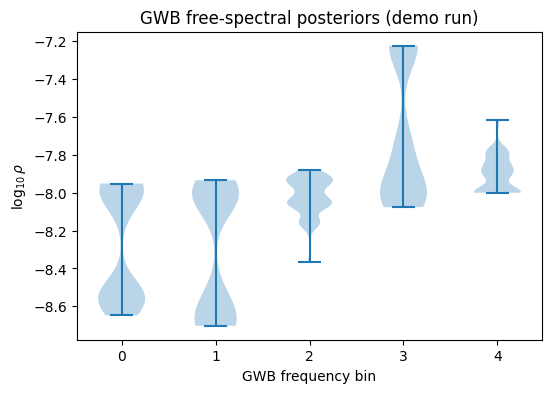

In [5]:
import h5py

with h5py.File('tests/data/demo_chain.h5', 'r') as f:
    par_names = [n.decode() for n in f['par_names'][:]]
    samples = f['samples_cold'][0, :, :]

idx_gwb_rho = [i for i, n in enumerate(par_names) if n.startswith('gwb_log10_rho')]

fig, ax = plt.subplots(figsize=(6, 4))
ax.violinplot([samples[:, i] for i in idx_gwb_rho], positions=np.arange(len(idx_gwb_rho)))
ax.set_xlabel('GWB frequency bin')
ax.set_ylabel(r'$\log_{10}\rho$')
ax.set_title('GWB free-spectral posteriors (demo run)')
plt.show()

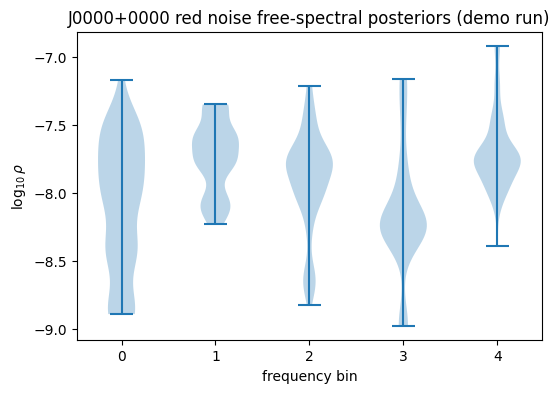

In [6]:
# per-pulsar free-spectral posteriors for the first pulsar
psr = psrs[0].name
idx_psr_rho = [i for i, n in enumerate(par_names) if n.startswith(psr + '_red_noise_log10_rho')]

fig, ax = plt.subplots(figsize=(6, 4))
ax.violinplot([samples[:, i] for i in idx_psr_rho], positions=np.arange(len(idx_psr_rho)))
ax.set_xlabel('frequency bin')
ax.set_ylabel(r'$\log_{10}\rho$')
ax.set_title(f'{psr} red noise free-spectral posteriors (demo run)')
plt.show()

## Other model combinations

All four combinations work the same way; only the two keyword arguments change:

```python
# power-law pulsar noise + power-law GWB (original QuickCW behavior)
pta, mcc = QCW.QuickCW(chain_params, psrs, noise_json=...,
                       psr_noise_model='powerlaw', gwb_noise_model='powerlaw')

# power-law pulsar noise + free-spectral GWB
pta, mcc = QCW.QuickCW(chain_params, psrs, noise_json=...,
                       psr_noise_model='powerlaw', gwb_noise_model='free_spectral')

# free-spectral pulsar noise + power-law GWB
pta, mcc = QCW.QuickCW(chain_params, psrs, noise_json=...,
                       psr_noise_model='free_spectral', gwb_noise_model='powerlaw')
```

Notes:

- With the free-spectral pulsar model, the parameters are named `{psr}_red_noise_log10_rho_{i}`; with the free-spectral GWB they are `gwb_log10_rho_{i}`.
- The `log10_rho` prior ranges can be changed with `QuickCW(..., log10_rho_prior=np.array([-9, -4]), gwb_log10_rho_prior=np.array([-9, -4]))`.
- RN empirical distribution proposals (`rn_emp_dist_file`) are only available with the power-law pulsar noise model.
- `zero_rn`/`zero_gwb` work with all models (free-spectral parameters are pinned to `-9`).